<h2>PreProcessing</h2>

In [1]:
%matplotlib ipympl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sunpy.map
from sunpy.net import Fido, attrs as a
from astropy import units as u
from astropy.coordinates import SkyCoord
import sunpy_soar
from glob import glob
from IPython.display import HTML
from astropy.io import fits
from astropy.time import Time
from datetime import datetime
#from pastamarkers import pasta, salsa
from stixpy.product import Product
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

In [3]:
plt.close('all')

In [4]:
short_exposure_images = glob(r'C:\python_code\hrishort\*.fits')

In [5]:
# initial_map = sunpy.map.Map(short_exposure_images[0])

In [6]:
# tr_x=3200
# tr_y=-550
# bl_x=3000
# bl_y=-800

In [7]:
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=initial_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=initial_map.coordinate_frame)
# short_exposure_map_seq = initial_map.submap(bottom_left=bottom_left, top_right=top_right)
# #short_exposure_map_seq.quicklook()

In [8]:
# second_map = sunpy.map.Map(short_exposure_images[1])
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=second_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=second_map.coordinate_frame)
# second_map_crop = second_map.submap(bottom_left=bottom_left, top_right=top_right)
# short_exposure_map_seq = sunpy.map.Map([short_exposure_map_seq, second_map_crop], sequence = True)
# third_map = sunpy.map.Map(short_exposure_images[2])
# top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=third_map.coordinate_frame)
# bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=third_map.coordinate_frame)
# third_map_crop = third_map.submap(bottom_left=bottom_left, top_right=top_right)
# short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [third_map_crop], sequence = True)

In [9]:
# for i in range(1346):
#     next_map = sunpy.map.Map(short_exposure_images[3+i])
#     top_right = SkyCoord(tr_x * u.arcsec, tr_y * u.arcsec, frame=next_map.coordinate_frame)
#     bottom_left = SkyCoord(bl_x * u.arcsec, bl_y * u.arcsec, frame=next_map.coordinate_frame)
#     next_map_crop = next_map.submap(bottom_left=bottom_left, top_right=top_right)
#     short_exposure_map_seq = sunpy.map.Map(short_exposure_map_seq.maps + [next_map_crop], sequence = True)

In [10]:
# short_exposure_map_seq2 = short_exposure_map_seq

<h2>Load in unmasked maps</h2>

In [11]:
index = 0
file_name = r'C:\Users\RH\miniforge3\Scripts\unmasked_map_seq\unmasked_map_'

In [12]:
# for i in range(1348):
#     short_exposure_map_seq[i].save(file_name + str(i) + '.fits')

In [13]:
initial_map = sunpy.map.Map(file_name + str(0) + '.fits')
second_map = sunpy.map.Map(file_name + str(1) + '.fits')
unmasked_map_seq = sunpy.map.Map(initial_map, [second_map], sequence = True)
for index in range(1346):
    n = str(index+2)
    filename = file_name + str(index) + '.fits'
    recall_map = sunpy.map.Map(filename)
    unmasked_map_seq = sunpy.map.Map(unmasked_map_seq.maps + [recall_map], sequence = True)

In [14]:
max = np.zeros(1345)
for i in range(1345):
    max[i] = (unmasked_map_seq[i]).max()

<h3>Load in 3% Threshold maps</h3>

In [15]:
# threshold = 0.03*max.max()
# initial_masked_3 = short_exposure_map_seq3[0]
# xdim = int(initial_masked_3.dimensions[0].value)
# ydim = int(initial_masked_3.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_3.data[i,j] < threshold:
#             initial_masked_3.data[i,j] = 0

In [16]:
# second_masked_3 = short_exposure_map_seq3[1]
# xdim = int(second_masked_3.dimensions[0].value)
# ydim = int(second_masked_3.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_3.data[i,j] < threshold:
#             second_masked_3.data[i,j] = 0

In [17]:
# masked_map_seq_3 = sunpy.map.Map([initial_masked_3, second_masked_3], sequence = True)

In [18]:
# for n in range(1346):
#     next_map = short_exposure_map_seq3[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_3 = sunpy.map.Map(masked_map_seq_3.maps + [next_map], sequence = True)

In [19]:
index = 0
file_name = r'C:\Users\RH\miniforge3\Scripts\masked_map_seq_3\masked_map_'

In [20]:
# for index in range(1348):
#     n = str(index)
#     filename = file_name + str(index) + '.fits'
#     masked_map_seq_3[index].save(filename)

In [21]:
initial_map = sunpy.map.Map(file_name + str(0) + '.fits')
second_map = sunpy.map.Map(file_name + str(1) + '.fits')
short_exposure_map_seq3 = sunpy.map.Map(initial_map, [second_map], sequence = True)
for index in range(1346):
    n = str(index+2)
    filename = file_name + str(index) + '.fits'
    recall_map = sunpy.map.Map(filename)
    short_exposure_map_seq3 = sunpy.map.Map(short_exposure_map_seq3.maps + [recall_map], sequence = True)

<h3>Load in 5% Threshold maps</h3>

In [22]:
# threshold = 0.05*max.max()
# initial_masked_5 = short_exposure_map_seq5[0]
# xdim = int(initial_masked_5.dimensions[0].value)
# ydim = int(initial_masked_5.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_5.data[i,j] < threshold:
#             initial_masked_5.data[i,j] = 0

In [23]:
# second_masked_5 = short_exposure_map_seq5[1]
# xdim = int(second_masked_5.dimensions[0].value)
# ydim = int(second_masked_5.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_5.data[i,j] < threshold:
#             second_masked_5.data[i,j] = 0

In [24]:
# masked_map_seq_5 = sunpy.map.Map([initial_masked_5, second_masked_5], sequence = True)

In [25]:
# for n in range(1343):
#     next_map = short_exposure_map_seq5[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_5 = sunpy.map.Map(masked_map_seq_5.maps + [next_map], sequence = True)

In [26]:
index = 0
file_name = r'C:\Users\RH\miniforge3\Scripts\masked_map_seq_5\masked_map_'

In [27]:
# for index in range(1345):
#     n = str(index)
#     filename = file_name + str(index) + '.fits'
#     masked_map_seq_5[index].save(filename)#, overwrite = True)

In [28]:
initial_map = sunpy.map.Map(file_name + str(0) + '.fits')
second_map = sunpy.map.Map(file_name + str(1) + '.fits')
short_exposure_map_seq5 = sunpy.map.Map(initial_map, [second_map], sequence = True)
for index in range(1346):
    n = str(index+2)
    filename = file_name + str(index) + '.fits'
    recall_map = sunpy.map.Map(filename)
    short_exposure_map_seq5 = sunpy.map.Map(short_exposure_map_seq5.maps + [recall_map], sequence = True)

<h3>Load in 10% Threshold maps</h3>

In [29]:
# threshold = 0.1*max.max()
# initial_masked_10 = short_exposure_map_seq[0]
# xdim = int(initial_masked_10.dimensions[0].value)
# ydim = int(initial_masked_10.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if initial_masked_10.data[i,j] < threshold:
#             initial_masked_10.data[i,j] = 0

In [30]:
# second_masked_10 = short_exposure_map_seq[1]
# xdim = int(second_masked_10.dimensions[0].value)
# ydim = int(second_masked_10.dimensions[1].value)
# for i in range(ydim):
#     for j in range(xdim):
#         if second_masked_10.data[i,j] < threshold:
#             second_masked_10.data[i,j] = 0

In [31]:
# masked_map_seq_10 = sunpy.map.Map([initial_masked_10, second_masked_10], sequence = True)

In [32]:
# for n in range(1347):
#     next_map = short_exposure_map_seq[2+n]
#     xdim = int(next_map.dimensions[0].value)
#     ydim = int(next_map.dimensions[1].value)
#     for i in range(ydim):
#         for j in range(xdim):
#             if next_map.data[i,j] < threshold:
#                 next_map.data[i,j] = 0
#     masked_map_seq_10 = sunpy.map.Map(masked_map_seq_10.maps + [next_map], sequence = True)

In [33]:
index = 0
file_name = r'C:\Users\RH\miniforge3\Scripts\masked_map_seq_10\masked_map_'

In [34]:
# for index in range(1348):
#     n = str(index)
#     filename = file_name + str(index) + '.fits'
#     masked_map_seq_10[index].save(filename)

In [35]:
initial_map = sunpy.map.Map(file_name + str(0) + '.fits')
second_map = sunpy.map.Map(file_name + str(1) + '.fits')
short_exposure_map_seq10 = sunpy.map.Map(initial_map, [second_map], sequence = True)
for index in range(1346):
    n = str(index+2)
    filename = file_name + str(index) + '.fits'
    recall_map = sunpy.map.Map(filename)
    short_exposure_map_seq10 = sunpy.map.Map(short_exposure_map_seq10.maps + [recall_map], sequence = True)

<h3>Watershed</h3>

In [36]:
masked_map_seq_3 = short_exposure_map_seq3
masked_map_seq_5 = short_exposure_map_seq5
masked_map_seq_10 = short_exposure_map_seq10

In [37]:
kernel_sizes = []

In [38]:
for n in range(65):
    index = 216 + n
    image = masked_map_seq_3[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero because i've set it up in a silly way
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [39]:
kernel_sizes_3 = kernel_sizes

In [40]:
kernel_sizes = []
for n in range(65):
    index = 216 + n
    image = masked_map_seq_5[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [41]:
kernel_sizes_5 = kernel_sizes

In [42]:
kernel_sizes = []
for n in range(65):
    index = 216 + n
    image = masked_map_seq_10[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [43]:
kernel_sizes_10 = kernel_sizes

In [44]:
# fig9 = plt.figure(figsize = (6,2))
# ax9 = fig9.add_subplot(111)
# ax9.hist(kernel_sizes_3, bins = 746, zorder = 6, color = "magenta")
# ax9.hist(kernel_sizes_5, bins = 746, zorder = 4, color = "blue")#, kernel_sizes)
# #ax9.hist(kernel_sizes_10, bins = 746, zorder = 1, color = "orange")
# ax9.set_xlabel("Kernel size")
# ax9.set_ylabel("Number of occurrences")
# ax9.set_yscale('log')
# #ax9.set_xlim(0,800)
# #ax3.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
# plt.show()

In [45]:
import plotly.graph_objects as go

import numpy as np

x0 = kernel_sizes_3
# Add 1 to shift the mean of the Gaussian distribution
x1 = kernel_sizes_5
x2 = kernel_sizes_10

fig = go.Figure()
fig.add_trace(go.Histogram(x=x0, name = "3%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))
fig.add_trace(go.Histogram(x=x1, name = "5%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))
fig.add_trace(go.Histogram(x=x2, name = "10%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))

# Overlay both histograms
fig.update_layout(barmode='overlay', # title of plot
    xaxis_title_text='Number of pixels in kernel', # xaxis label
    yaxis_title_text='Number of occurrences')
# Reduce opacity to see both histograms
fig.update_traces(opacity=0.75)
#fig.update_xaxes(type="log", range = [0,3])
fig.update_yaxes(type="log", range = [0,2])
fig.show()

In [46]:
number_unresolved_3 = 0
number_unresolved_5 = 0
number_unresolved_10 = 0

In [47]:
loops = kernel_sizes_3.shape[0]
for i in range(loops):
    if kernel_sizes_3[i] <= 9:
        number_unresolved_3 = number_unresolved_3 + 1

In [48]:
loops = kernel_sizes_5.shape[0]
for i in range(loops):
    if kernel_sizes_5[i] <= 9:
        number_unresolved_5 = number_unresolved_5 + 1

In [49]:
loops = kernel_sizes_10.shape[0]
for i in range(loops):
    if kernel_sizes_10[i] <= 9:
        number_unresolved_10 = number_unresolved_10 + 1

In [50]:
number_unresolved_3/(kernel_sizes_3.shape[0])

0.5908203125

In [51]:
number_unresolved_5/(kernel_sizes_5.shape[0])

0.65086887835703

In [52]:
number_unresolved_10/(kernel_sizes_10.shape[0])

0.6696969696969697

<h3>Running Difference Data - 3%</h3>

In [53]:
n_data = masked_map_seq_3[0].data
n1_data = masked_map_seq_3[1].data

In [54]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [55]:
initial_diff_3_data = masked_map_seq_3[1].data - masked_map_seq_3[0].data
coord = masked_map_seq_3[1].reference_coordinate
pixel = masked_map_seq_3[1].reference_pixel
scale = masked_map_seq_3[1].scale
wl = masked_map_seq_3[1].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_3_data, coord, pixel*u.pixel, wavelength = wl)

first_map = sunpy.map.Map(initial_diff_3_data, header)

In [56]:
n_data = masked_map_seq_3[1].data
n1_data = masked_map_seq_3[2].data

In [57]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [58]:
initial_diff_3_data = n1_data - n_data
coord = masked_map_seq_3[2].reference_coordinate
pixel = masked_map_seq_3[2].reference_pixel
scale = masked_map_seq_3[2].scale
wl = masked_map_seq_3[2].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_3_data, coord, pixel*u.pixel, wavelength = wl)

second_map = sunpy.map.Map(initial_diff_3_data, header)

In [59]:
running_diff_3 = sunpy.map.Map([first_map, second_map], sequence = True)

In [60]:
for n in range(1346):
    n_data = masked_map_seq_3[n].data
    n1_data = masked_map_seq_3[n+1].data

    #check map data is same size and remove row/column if not
    if n1_data.shape[1] > n_data.shape[1]:
        n1_data = np.delete(n1_data, 1, 1)
    if n1_data.shape[0] > n_data.shape[0]:
        n1_data = np.delete(n1_data, 0, 0)
    if n_data.shape[1] > n1_data.shape[1]:
        n_data = np.delete(n_data, 1, 1)
    if n_data.shape[0] > n1_data.shape[0]:
        n_data = np.delete(n_data, 0, 0)

    #subtract
    diff_data = n1_data - n_data

    #create header
    coord = masked_map_seq_3[n+1].reference_coordinate
    pixel = masked_map_seq_3[n+1].reference_pixel
    scale = masked_map_seq_3[n+1].scale
    wl = masked_map_seq_3[n+1].wavelength
    header = sunpy.map.make_fitswcs_header(diff_data, coord, pixel*u.pixel, wavelength = wl)

    #create map
    next_map = sunpy.map.Map(diff_data, header)

    #add to map sequence
    running_diff_3 = sunpy.map.Map(running_diff_3.maps + [next_map], sequence = True)

In [61]:
# number_of_pixels = np.zeros(1348)
# for i in range(1348):
#     print(i)
#     diff = running_diff_3[i].data
#     xdim = int(diff.shape[0])
#     ydim = int(diff.shape[1])
#     for x in range(xdim):
#         for y in range(ydim):
#             if diff[x,y] < 0:
#                 diff[x,y] = 0
#             if diff[x,y] != 0:
#                 number_of_pixels[i+1] = number_of_pixels[i+1] + 1

<h3>Running Difference Data - 5%</h3>

In [62]:
n_data = masked_map_seq_5[0].data
n1_data = masked_map_seq_5[1].data

In [63]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [64]:
initial_diff_5_data = masked_map_seq_5[1].data - masked_map_seq_5[0].data
coord = masked_map_seq_5[1].reference_coordinate
pixel = masked_map_seq_5[1].reference_pixel
scale = masked_map_seq_5[1].scale
wl = masked_map_seq_5[1].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_5_data, coord, pixel*u.pixel, wavelength = wl)

first_map = sunpy.map.Map(initial_diff_5_data, header)

In [65]:
n_data = masked_map_seq_5[1].data
n1_data = masked_map_seq_5[2].data

In [66]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [67]:
initial_diff_5_data = n1_data - n_data
coord = masked_map_seq_5[2].reference_coordinate
pixel = masked_map_seq_5[2].reference_pixel
scale = masked_map_seq_5[2].scale
wl = masked_map_seq_5[2].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_5_data, coord, pixel*u.pixel, wavelength = wl)

second_map = sunpy.map.Map(initial_diff_5_data, header)

In [68]:
running_diff_5 = sunpy.map.Map([first_map, second_map], sequence = True)

In [69]:
for n in range(1346):
    n_data = masked_map_seq_5[n].data
    n1_data = masked_map_seq_5[n+1].data

    #check map data is same size and remove row/column if not
    if n1_data.shape[1] > n_data.shape[1]:
        n1_data = np.delete(n1_data, 1, 1)
    if n1_data.shape[0] > n_data.shape[0]:
        n1_data = np.delete(n1_data, 0, 0)
    if n_data.shape[1] > n1_data.shape[1]:
        n_data = np.delete(n_data, 1, 1)
    if n_data.shape[0] > n1_data.shape[0]:
        n_data = np.delete(n_data, 0, 0)

    #subtract
    diff_data = n1_data - n_data

    #create header
    coord = masked_map_seq_5[n+1].reference_coordinate
    pixel = masked_map_seq_5[n+1].reference_pixel
    scale = masked_map_seq_5[n+1].scale
    wl = masked_map_seq_5[n+1].wavelength
    header = sunpy.map.make_fitswcs_header(diff_data, coord, pixel*u.pixel, wavelength = wl)

    #create map
    next_map = sunpy.map.Map(diff_data, header)

    #add to map sequence
    running_diff_5 = sunpy.map.Map(running_diff_5.maps + [next_map], sequence = True)

<h3>Running Difference - 10%</h3>

In [70]:
n_data = masked_map_seq_10[0].data
n1_data = masked_map_seq_10[1].data

In [71]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [72]:
initial_diff_10_data = n1_data - n_data
coord = masked_map_seq_10[1].reference_coordinate
pixel = masked_map_seq_10[1].reference_pixel
scale = masked_map_seq_10[1].scale
wl = masked_map_seq_10[1].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_10_data, coord, pixel*u.pixel, wavelength = wl)

first_map = sunpy.map.Map(initial_diff_10_data, header)

In [73]:
n_data = masked_map_seq_10[1].data
n1_data = masked_map_seq_10[2].data

In [74]:
if n1_data.shape[1] > n_data.shape[1]:
    n1_data = np.delete(n1_data, 1, 1)
if n1_data.shape[0] > n_data.shape[0]:
    n1_data = np.delete(n1_data, 0, 0)
if n_data.shape[1] > n1_data.shape[1]:
    n_data = np.delete(n_data, 1, 1)
if n_data.shape[0] > n1_data.shape[0]:
    n_data = np.delete(n_data, 0, 0)

In [75]:
initial_diff_10_data = n1_data - n_data
coord = masked_map_seq_10[2].reference_coordinate
pixel = masked_map_seq_10[2].reference_pixel
scale = masked_map_seq_10[2].scale
wl = masked_map_seq_10[2].wavelength

header = sunpy.map.make_fitswcs_header(initial_diff_10_data, coord, pixel*u.pixel, wavelength = wl)

second_map = sunpy.map.Map(initial_diff_10_data, header)

In [76]:
running_diff_10 = sunpy.map.Map([first_map, second_map], sequence = True)

In [77]:
for n in range(1346):
    n_data = masked_map_seq_10[n].data
    n1_data = masked_map_seq_10[n+1].data

    #check map data is same size and remove row/column if not
    if n1_data.shape[1] > n_data.shape[1]:
        n1_data = np.delete(n1_data, 1, 1)
    if n1_data.shape[0] > n_data.shape[0]:
        n1_data = np.delete(n1_data, 0, 0)
    if n_data.shape[1] > n1_data.shape[1]:
        n_data = np.delete(n_data, 1, 1)
    if n_data.shape[0] > n1_data.shape[0]:
        n_data = np.delete(n_data, 0, 0)

    #subtract
    diff_data = n1_data - n_data

    #create header
    coord = masked_map_seq_10[n+1].reference_coordinate
    pixel = masked_map_seq_10[n+1].reference_pixel
    scale = masked_map_seq_10[n+1].scale
    wl = masked_map_seq_10[n+1].wavelength
    header = sunpy.map.make_fitswcs_header(diff_data, coord, pixel*u.pixel, wavelength = wl)

    #create map
    next_map = sunpy.map.Map(diff_data, header)

    #add to map sequence
    running_diff_10 = sunpy.map.Map(running_diff_10.maps + [next_map], sequence = True)

<h3>Counts Plot</h3>

In [78]:
number_of_pixels_3 = np.zeros(1348)
number_of_pixels_5 = np.zeros(1348)
number_of_pixels_10 = np.zeros(1348)
for i in range(1347):
    diff_3 = running_diff_3[i].data 
    xdim = int(diff_3.shape[0])
    ydim = int(diff_3.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff_3[x,y] < 0:
                diff_3[x,y] = 0
            if diff_3[x,y] != 0:
                number_of_pixels_3[i+1] = number_of_pixels_3[i+1] + 1

In [79]:
for i in range(1347):
    diff_5 = running_diff_5[i].data
    xdim = int(diff_5.shape[0])
    ydim = int(diff_5.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff_5[x,y] < 0:
                diff_5[x,y] = 0
            if diff_5[x,y] != 0:
                number_of_pixels_5[i+1] = number_of_pixels_5[i+1] + 1

In [80]:
for i in range(1347):
    diff_10 = running_diff_10[i].data 
    xdim = int(diff_10.shape[0])
    ydim = int(diff_10.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff_10[x,y] < 0:
                diff_10[x,y] = 0
            if diff_10[x,y] != 0:
                number_of_pixels_10[i+1] = number_of_pixels_10[i+1] + 1

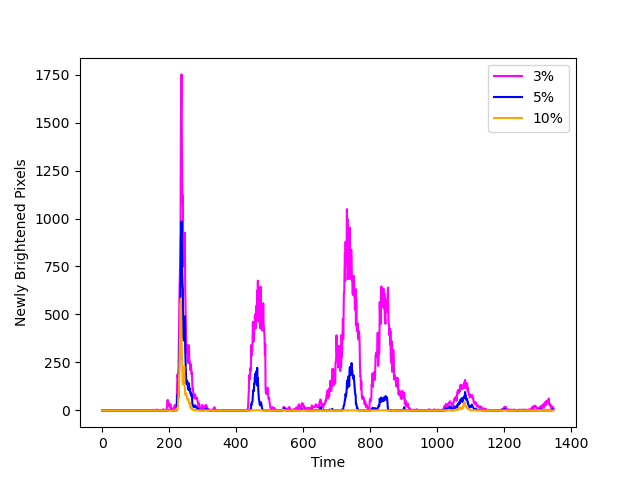

In [81]:
x = np.linspace(1, 1348, 1348)
fig4 = plt.figure()
ax4 = fig4.add_subplot(111)
ax4.plot(x, number_of_pixels_3, 'magenta', label = "3%")
ax4.plot(x, number_of_pixels_5, 'blue', label = "5%")
ax4.plot(x, number_of_pixels_10, 'orange', label = "10%")
ax4.set_xlabel("Time")
ax4.set_ylabel("Newly Brightened Pixels")
#ax4.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
ax4.legend()
plt.show()

<h3>Watershed - Running Difference</h3>

In [82]:
kernel_sizes = []

In [83]:
for n in range(65):
    index = 216 + n
    image = running_diff_3[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero because i've set it up in a silly way
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [84]:
kernel_sizes_3_diff = kernel_sizes

In [85]:
kernel_sizes = []
for n in range(65):
    index = 216 + n
    image = running_diff_5[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [86]:
kernel_sizes_5_diff = kernel_sizes

In [87]:
kernel_sizes = []
for n in range(65):
    index = 216 + n
    image = running_diff_10[index].data
    distance = ndi.distance_transform_edt(image)
    coords = peak_local_max(distance, min_distance = 4)
    mask = np.zeros(distance.shape, dtype=bool)
    mask[tuple(coords.T)] = True
    markers, _ = ndi.label(mask)
    labels = watershed(-distance, markers, mask=image)
    
    if labels.max() != 0:
        frame_kernel_sizes = np.zeros(labels.max()+1)
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] != 0:
                    label = labels[i,j]
                    frame_kernel_sizes[label] = frame_kernel_sizes[label] + 1
        #need to drop first element of frame_kernel_sizes because it will always be zero
        frame_kernel_sizes = frame_kernel_sizes[1:]
        #need to append frame_kernel_sizes to kernel_sizes so i can plot a histogram
        kernel_sizes = np.concatenate((kernel_sizes, frame_kernel_sizes))

In [88]:
kernel_sizes_10_diff = kernel_sizes

In [89]:
import plotly.graph_objects as go

import numpy as np

x0 = kernel_sizes_3_diff
x1 = kernel_sizes_5_diff
x2 = kernel_sizes_10_diff

fig = go.Figure()
fig.add_trace(go.Histogram(x=x0, name = "3%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))
fig.add_trace(go.Histogram(x=x1, name = "5%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))
fig.add_trace(go.Histogram(x=x2, name = "10%",
                           xbins=dict( # bins used for histogram
                            start=0.0,
                            end=200,
                            size=1
                        )))

# Overlay both histograms
fig.update_layout(barmode='overlay', # title of plot
    xaxis_title_text='Number of pixels in kernel', # xaxis label
    yaxis_title_text='Number of occurrences')
# Reduce opacity to see both histograms
fig.update_traces(opacity=0.75)
#fig.update_xaxes(type="log", range = [0,3])
fig.update_yaxes(type="log", range = [0,2])
fig.show()

In [90]:
number_unresolved_3_diff = 0
number_unresolved_5_diff = 0
number_unresolved_10_diff = 0

In [91]:
loops = kernel_sizes_3_diff.shape[0]
for i in range(loops):
    if kernel_sizes_3_diff[i] <= 9:
        number_unresolved_3_diff = number_unresolved_3_diff + 1

In [92]:
loops = kernel_sizes_5_diff.shape[0]
for i in range(loops):
    if kernel_sizes_5_diff[i] <= 9:
        number_unresolved_5_diff = number_unresolved_5_diff + 1

In [93]:
loops = kernel_sizes_10_diff.shape[0]
for i in range(loops):
    if kernel_sizes_10_diff[i] <= 9:
        number_unresolved_10_diff = number_unresolved_10_diff + 1

In [94]:
number_unresolved_3_diff/(kernel_sizes_3_diff.shape[0])

0.5477815699658704

In [95]:
number_unresolved_5_diff/(kernel_sizes_5_diff.shape[0])

0.58203125

In [96]:
number_unresolved_10_diff/(kernel_sizes_10_diff.shape[0])

0.6202830188679245

<h3>Figure 5</h3>

In [97]:
euitimes = []
for i in range(1348):
    hdul = fits.open(short_exposure_images[i])
    hdu1 = hdul[1]
    euitimes.append(hdu1.header["DATE-BEG"])
    hdul.close()

In [98]:
euitimes = Time(euitimes)

In [99]:
intensity = np.zeros(1348)
for n in range(1348):
    intensity[n] = np.sum(masked_map_seq_5[n].data)

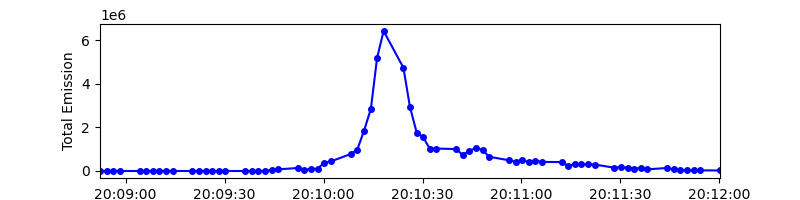

In [100]:
fig3 = plt.figure(figsize=(8,2))
ax3 = fig3.add_subplot(111)
ax3.plot(euitimes.to_datetime(), intensity, 'bo-', ms = 4)
ax3.set_xlabel("Time")
ax3.set_ylabel("Total Emission")
ax3.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

In [101]:
pixel_count_5 = np.zeros(1348)
for i in range(1347):
    diff_5 = masked_map_seq_5[i].data
    xdim = int(diff_5.shape[0])
    ydim = int(diff_5.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff_5[x,y] < 0:
                diff_5[x,y] = 0
            if diff_5[x,y] != 0:
                pixel_count_5[i+1] = pixel_count_5[i+1] + 1

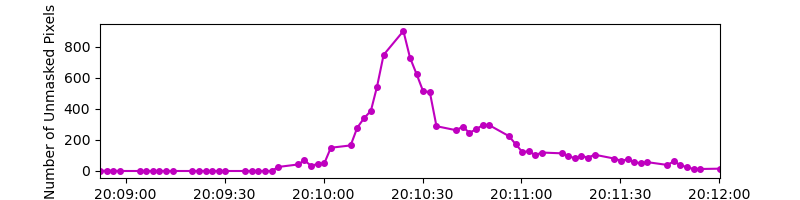

In [102]:
fig4 = plt.figure(figsize=(8,2))
ax4 = fig4.add_subplot(111)
ax4.plot(euitimes.to_datetime(), pixel_count_5, 'mo-', ms = 4)
ax4.set_xlabel("Time")
ax4.set_ylabel("Number of Unmasked Pixels")
ax4.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

In [103]:
normal_number_pixels = pixel_count_5
for i in range(1348):
    if pixel_count_5[i] == 0:
        normal_number_pixels = 1
normalised_emission = intensity/normal_number_pixels

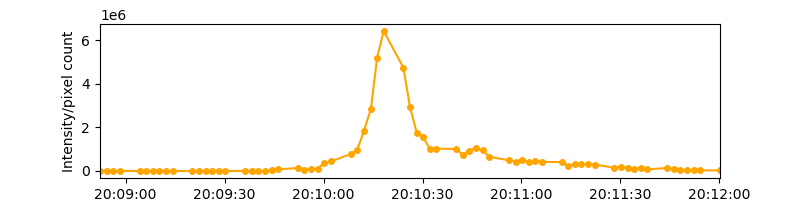

In [104]:
fig5 = plt.figure(figsize=(8,2))
ax5 = fig5.add_subplot(111)
ax5.plot(euitimes.to_datetime(), normalised_emission, 'orange', marker = 'o', linestyle = '-', ms = 4)
ax5.set_xlabel("Time")
ax5.set_ylabel("Intensity/pixel count")
ax5.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

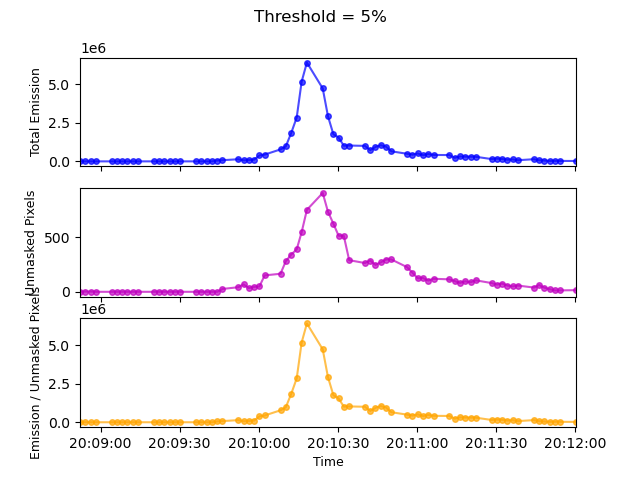

In [105]:
fig8, (axa, axb, axc) = plt.subplots(3, sharex=True)
fig8.suptitle('Threshold = 5%')

axa.plot(euitimes.to_datetime(), intensity, 'bo-', ms = 4, alpha = 0.7)
axa.set_ylabel("Total Emission", fontsize = 9)

axb.plot(euitimes.to_datetime(), pixel_count_5, 'mo-', ms = 4, alpha = 0.7)
axb.set_ylabel("Unmasked Pixels", fontsize = 9)

axc.plot(euitimes.to_datetime(), normalised_emission, 'orange', marker = 'o', linestyle = '-', ms = 4, alpha = 0.7)
axc.set_ylabel("Emission / Unmasked Pixels", fontsize = 9)

axc.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
axc.set_xlabel("Time", fontsize = 9)
plt.show()

In [106]:
number_of_pixels_flare = pixel_count_5[200:270]
intensity_flare = intensity[200:270]

In [107]:
time_since_flare = []
seconds_since_flare = np.zeros(70)
for i in range(41):
    time_since_flare.append(euitimes[200+i].to_datetime() - euitimes[200].to_datetime())
    seconds_since_flare[i] = time_since_flare[i].seconds

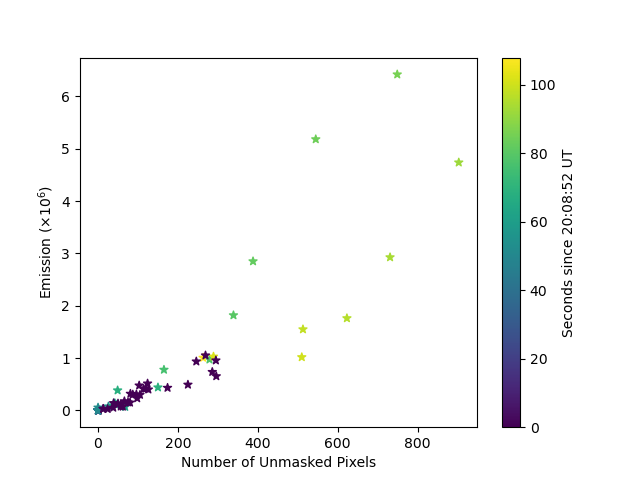

In [108]:
fig7 = plt.figure()
ax7 = fig7.add_subplot(1,1,1)

sc = ax7.scatter(number_of_pixels_flare, intensity_flare/1e6, c=seconds_since_flare, marker="*")#, vmin = 0, vmax = 7)
ax7.set_xlabel("Number of Unmasked Pixels")
ax7.set_ylabel(r"Emission ($\times 10^6$)")
plt.colorbar(sc,label=r'Seconds since 20:08:52 UT')
plt.show()

<h3>Total Ribbon Area vs New Pixel Area</h3>

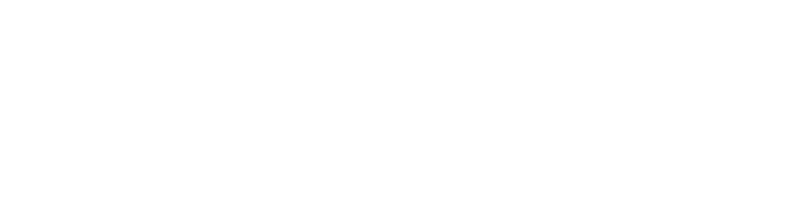

In [109]:
fig6 = plt.figure(figsize=(8,2))
ax6 = fig5.add_subplot(111)
ax6.plot(euitimes.to_datetime(), number_of_pixels_5, 'orange', marker = 'o', linestyle = '-', ms = 4)
ax6.set_xlabel("Time")

ax7 = ax6.twinx()
ax7.plot(euitimes.to_datetime(), pixel_count_5, 'mo-', ms = 4)
ax7.set_ylabel("Number of Unmasked Pixels")

ax6.set_ylabel("Number of New Pixels")
ax6.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
plt.show()

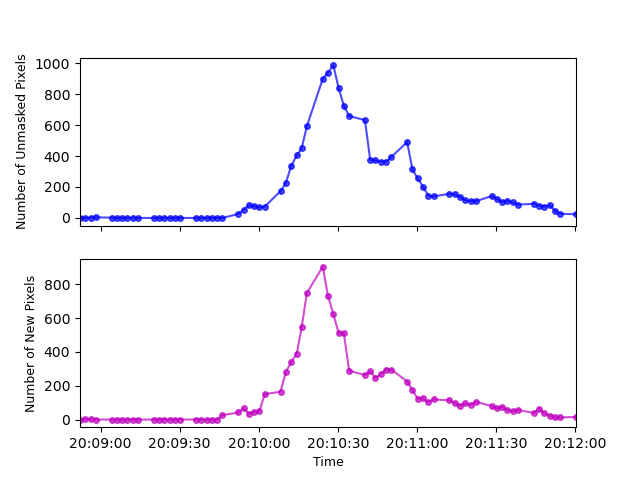

In [110]:
fig9, (axd, axe) = plt.subplots(2, sharex=True)
fig8.suptitle('Threshold = 5%')

axd.plot(euitimes.to_datetime(), number_of_pixels_5, 'bo-', ms = 4, alpha = 0.7)
axd.set_ylabel("Number of Unmasked Pixels", fontsize = 9)

axe.plot(euitimes.to_datetime(), pixel_count_5, 'mo-', ms = 4, alpha = 0.7)
axe.set_ylabel("Number of New Pixels", fontsize = 9)

axe.set_xlim(euitimes[200].to_datetime(), euitimes[270].to_datetime())
axe.set_xlabel("Time", fontsize = 9)
plt.show()

<h3>Watershed Visualisation</h3>

In [111]:
image = short_exposure_map_seq5[231].data#.transpose()

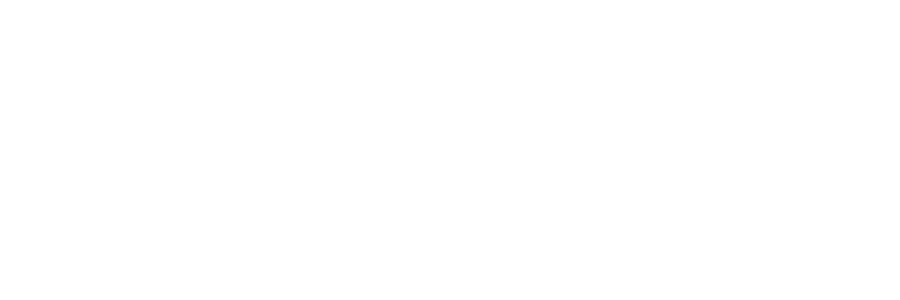

In [112]:
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, min_distance = 4, num_peaks_per_label = 1)#, labels = image)#, footprint=np.ones((3, 3)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

#labels = watershed(image)

fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(np.flipud(image), cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(np.flipud(-distance), cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(np.flipud(labels), cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

# for a in ax:
#     a.set_axis_off()

fig.tight_layout()
plt.show()

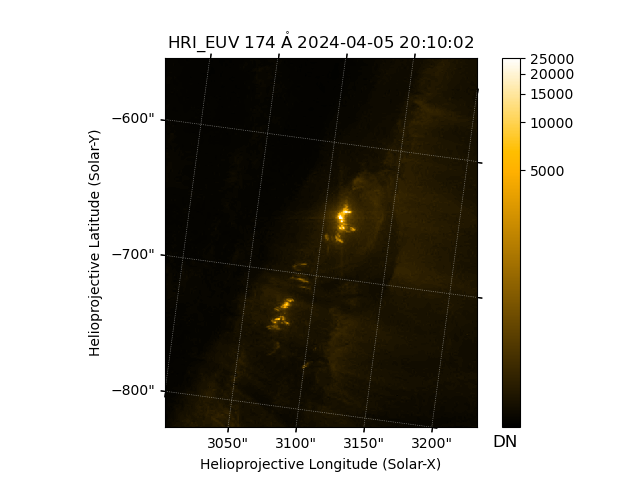

In [113]:
unmasked_map_seq[229].peek()

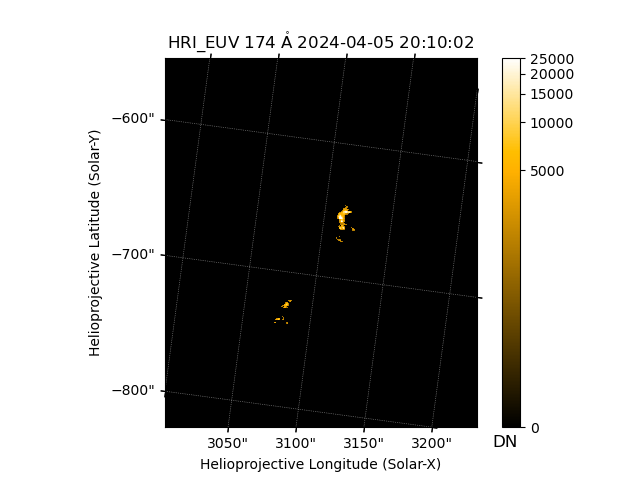

In [114]:
short_exposure_map_seq5[231].peek()

In [115]:
# distance = ndi.distance_transform_edt(image)
# coords = peak_local_max(distance, min_distance = 4, num_peaks_per_label = 1)#, labels = image)#, footprint=np.ones((3, 3)), labels=image)
# mask = np.zeros(distance.shape, dtype=bool)
# mask[tuple(coords.T)] = True
# markers, _ = ndi.label(mask)
# labels = watershed(-distance, markers, mask=image)

# #labels = watershed(image)

# fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
# ax = axes.ravel()

# unmasked_map_seq[229].plot(axes=ax[0], projection=unmasked_map_seq[229].wcs)#, clip_interval=(1, 99.9)*u.percent, zorder=0)
# #ax[0].imshow(image, cmap=plt.cm.gray)
# ax[0].set_title('Original Data')
# short_exposure_map_seq5[229].plot(axes=ax[1], projection=short_exposure_map_seq5[229].wcs)
# #ax[1].imshow(-distance, cmap=plt.cm.gray)
# ax[1].set_title('Masked Data')
# ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
# ax[2].set_title('Separated objects')

# # for a in ax:
# #     a.set_axis_off()

# fig.tight_layout()
# plt.show()

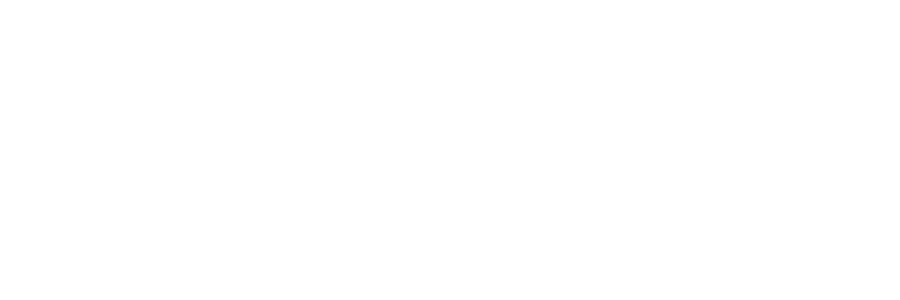

In [116]:
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, min_distance = 4, num_peaks_per_label = 1)#, labels = image)#, footprint=np.ones((3, 3)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

#labels = watershed(image)

fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(unmasked_map_seq[229].data, cmap='solar orbiterhri_euv174')
ax[0].set_title('Original Data')
ax[1].imshow(short_exposure_map_seq5[231].data, cmap='solar orbiterhri_euv174')
ax[1].set_title('Threshold = 5%')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Kernels')

# for a in ax:
#     a.set_axis_off()

fig.tight_layout()
plt.show()

<h3>STIX v EUI Brightenings</h3>

In [117]:
from glob import glob
stix_data = glob(r'C:\python_code\stix_test\stix_data\*.fits')

In [118]:
spec_5_10 = np.zeros(7000)
spec_10_15 = np.zeros(7000)
spec_15_25 = np.zeros(7000)
spec_25_50 = np.zeros(7000)
spec_22_45 = np.zeros(7000)

In [119]:
spec = Product(stix_data[4])

In [120]:
for i in range(7000):
    spec_5_10[i] = (spec.data['counts'][i, 2].value + spec.data['counts'][i, 3].value 
                    + spec.data['counts'][i, 4].value + spec.data['counts'][i, 5].value + spec.data['counts'][i, 6].value)
    spec_10_15[i] = (spec.data['counts'][i, 7].value + spec.data['counts'][i, 8].value 
                    + spec.data['counts'][i, 9].value + spec.data['counts'][i, 10].value + spec.data['counts'][i, 11].value)
    spec_15_25[i] = (spec.data['counts'][i, 12].value + spec.data['counts'][i, 13].value 
                    + spec.data['counts'][i, 14].value + spec.data['counts'][i, 15].value + spec.data['counts'][i, 16].value)
    spec_25_50[i] = (spec.data['counts'][i, 17].value + spec.data['counts'][i, 18].value 
                    + spec.data['counts'][i, 19].value + spec.data['counts'][i, 20].value + spec.data['counts'][i, 21].value
                    + spec.data['counts'][i, 22].value)
    spec_22_45[i] = (spec.data['counts'][i, 16].value + spec.data['counts'][i, 17].value + spec.data['counts'][i, 18].value 
                    + spec.data['counts'][i, 19].value + spec.data['counts'][i, 20].value + spec.data['counts'][i, 21].value)

In [121]:
stix_times = spec.data['time']

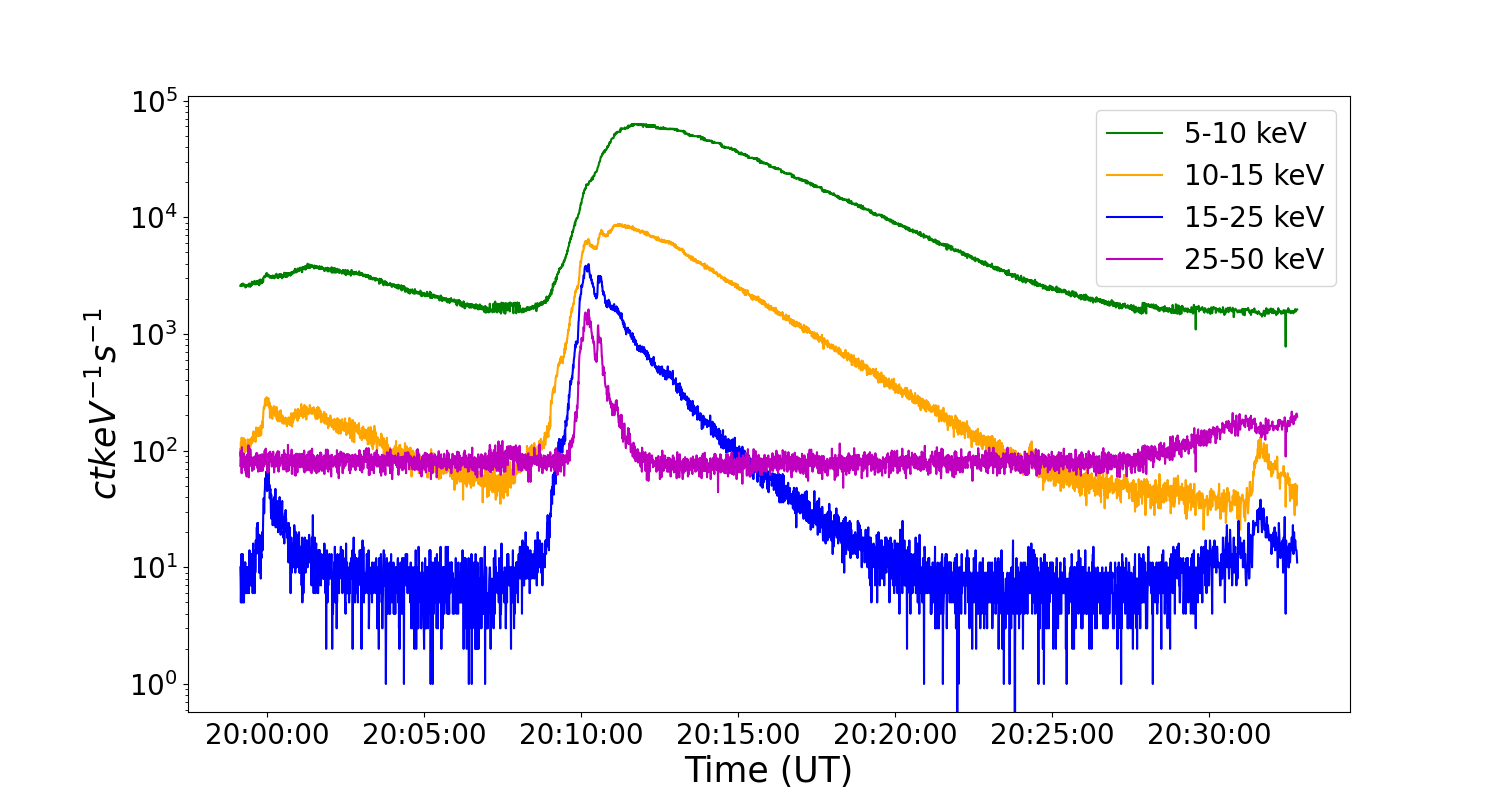

In [122]:
start = 500
end = 4300
label_size = 25
tick_size = 20
fig11 = plt.figure(figsize = (15,8))
ax11= fig11.add_subplot(111)
ax11.plot(stix_times[start:end].to_datetime(), spec_5_10[start:end], color ='g', label = "5-10 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_10_15[start:end], color ='orange', label = "10-15 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_15_25[start:end], color ='blue', label = "15-25 keV")#, linestyle = 'None', marker = 'x')
ax11.plot(stix_times[start:end].to_datetime(), spec_25_50[start:end], color ='m', label = "25-50 keV")#, linestyle = 'None', marker = 'x')
ax11.set_ylabel("$ct keV^{-1} s^{-1}$", fontsize = label_size)
ax11.set_xticks([datetime(2024,4,5,20,00,0,0), datetime(2024,4,5,20,5,0,0), datetime(2024,4,5,20,10,0,0), datetime(2024,4,5,20,15,0,0), 
                 datetime(2024,4,5,20,20,0,0), datetime(2024,4,5,20,25,0,0), datetime(2024,4,5,20,30,0,0)],
               ['20:00:00', '20:05:00', '20:10:00', '20:15:00', '20:20:00', '20:25:00', '20:30:00'], fontsize = tick_size)
ax11.set_xlabel("Time (UT)", fontsize = label_size)
ax11.set_yscale('log')
#ax11.set_yticks(fontsize = 15)
for label in ax11.get_yticklabels():
    label.set_fontsize(tick_size)

ax11.legend(loc = 1, fontsize = tick_size)
plt.show()

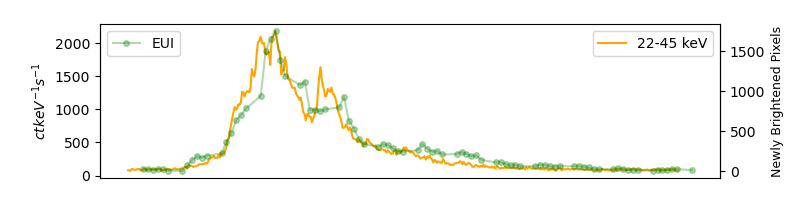

In [123]:
start2 = 1700
end2 = 2150
start3 = 215
end3 = 300
fig12 = plt.figure(figsize = (8,2))
ax12 = fig12.add_subplot(111)
ax12.plot(stix_times[start2:end2].to_datetime(), spec_22_45[start2:end2], color ='orange', label = "22-45 keV")#, linestyle = 'None', marker = 'x')
ax12.set_ylabel("$ct keV^{-1} s^{-1}$")
ax13 = ax12.twinx()

ax13.plot(euitimes[start3-5:end3-5].to_datetime(), number_of_pixels_3[start3:end3], marker = "o", markersize = 4, linestyle = "-", color = "green", alpha = 0.3, label = "EUI")
ax13.set_ylabel("Newly Brightened Pixels", fontsize = 9)

ax12.legend(loc = 0)
ax13.legend(loc = 2)
plt.show()

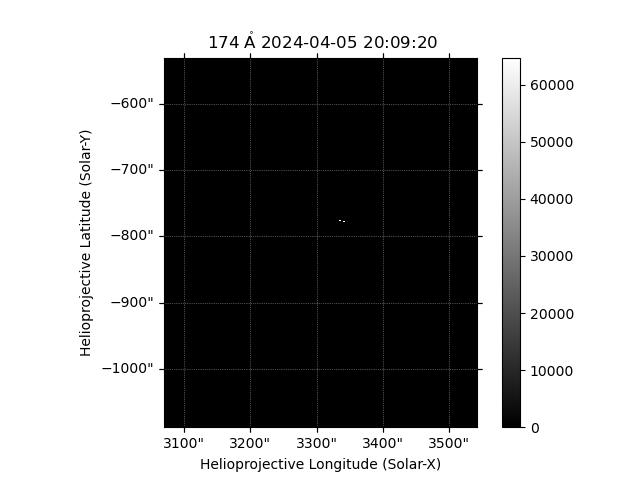

In [124]:
running_diff_3[215].peek()

In [125]:
euitimes[210]

<Time object: scale='utc' format='isot' value=2024-04-05T20:09:20.197>

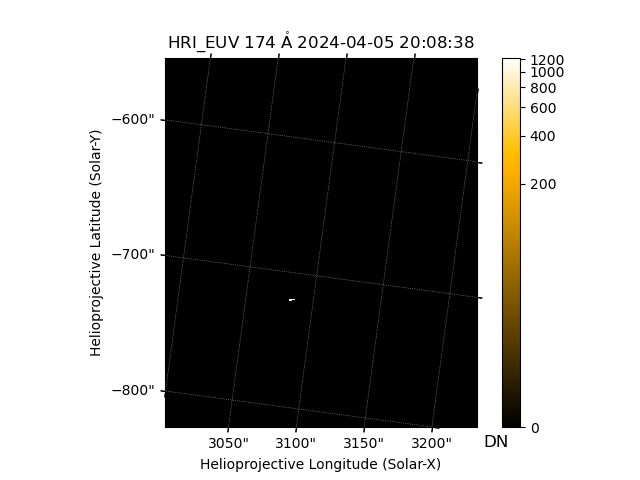

In [126]:
masked_map_seq_3[199].peek()

In [127]:
pixel_time_3 = []
pixel_num_3 = np.zeros(1348)
for i in range(1347):
    diff_3 = running_diff_3[i].data 
    pixel_time_3.append(running_diff_3[i].observer_coordinate.obstime)
    xdim = int(diff_3.shape[0])
    ydim = int(diff_3.shape[1])
    for x in range(xdim):
        for y in range(ydim):
            if diff_3[x,y] < 0:
                diff_3[x,y] = 0
            if diff_3[x,y] != 0:
                pixel_num_3[i+1] = pixel_num_3[i+1] + 1

In [128]:
stix_times[1]

<Time object: scale='utc' format='isot' value=2024-04-05T19:54:59.567>

In [129]:
pixel_time_3 = Time(pixel_time_3)

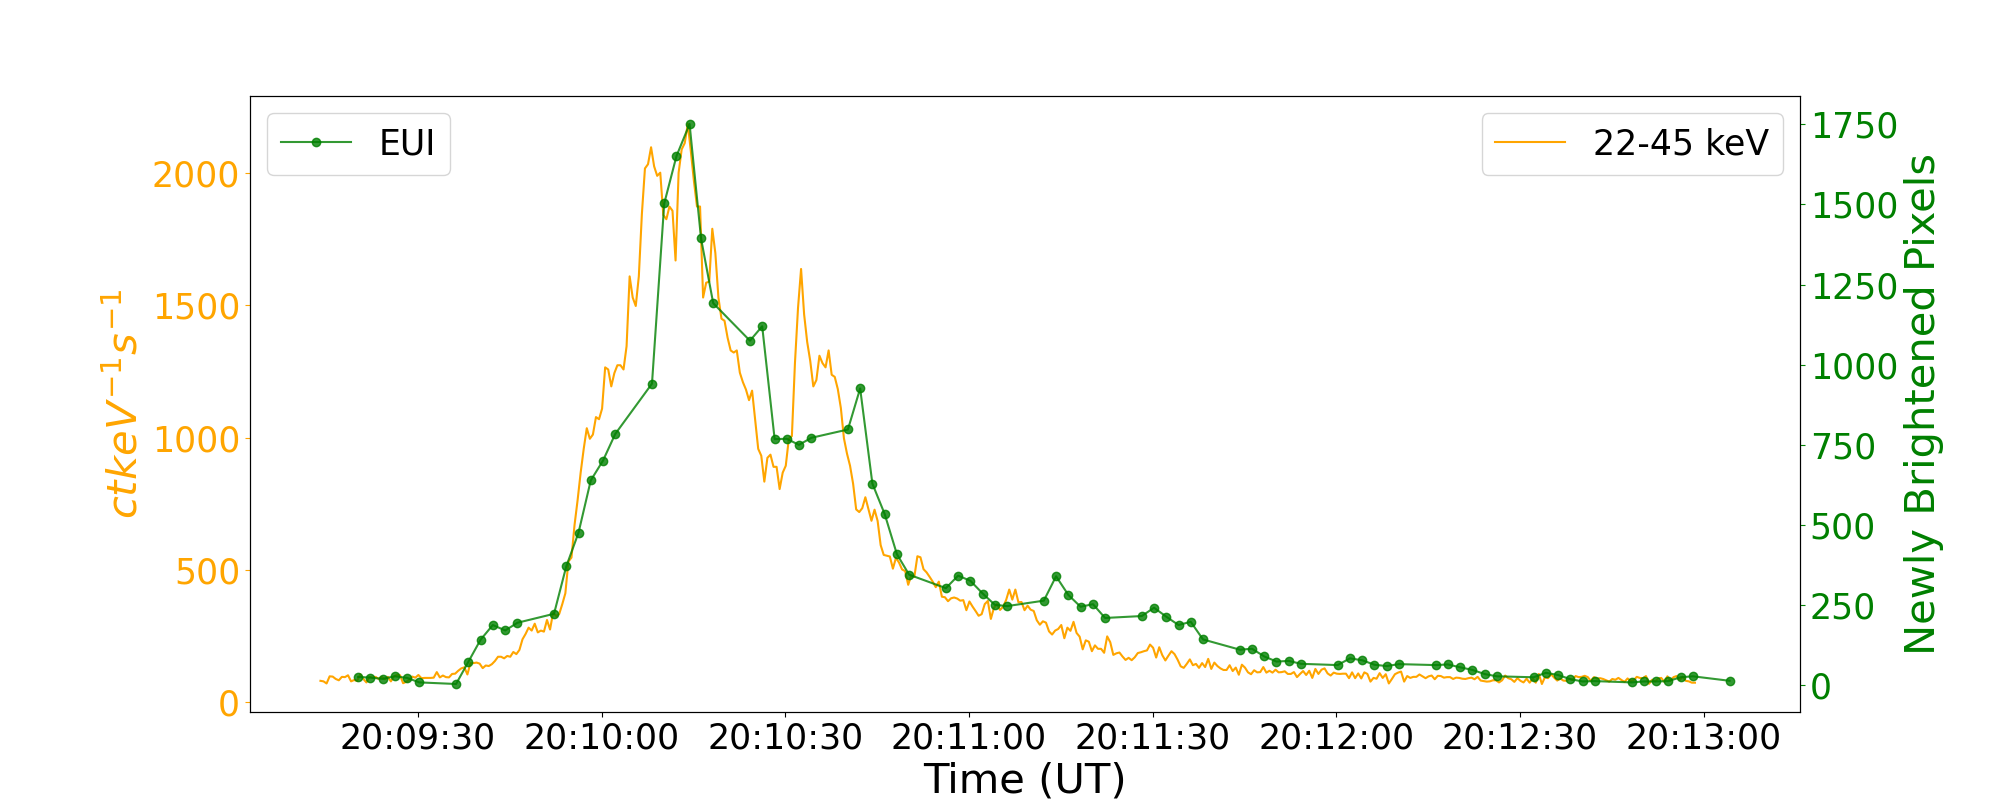

In [130]:
start2 = 1700
end2 = 2150
start3 = 215
end3 = 300
label_size = 30
tick_size = 25
fig12 = plt.figure(figsize = (20,8))
ax12 = fig12.add_subplot(111)
ax12.plot(stix_times[start2:end2].to_datetime(), spec_22_45[start2:end2], color ='orange', label = "22-45 keV")#, linestyle = 'None', marker = 'x')
ax12.set_ylabel("$ct keV^{-1} s^{-1}$", fontsize = label_size, color = 'orange')
ax13 = ax12.twinx()

ax13.plot(pixel_time_3[start3:end3].to_datetime(), pixel_num_3[start3:end3], marker = "o", markersize = 6, linestyle = "-", color = "green", alpha = 0.8, label = "EUI")
ax13.set_ylabel("Newly Brightened Pixels", fontsize = label_size, color = 'green')

ax12.set_xlabel("Time (UT)", fontsize = label_size)

ax12.tick_params(axis='both', which='major', labelsize=tick_size)
ax12.tick_params(axis='y', colors = 'orange')
ax12.tick_params(axis='both', which='minor', labelsize=tick_size)
ax13.tick_params(axis='both', which='major', labelsize=tick_size)
ax13.tick_params(axis='y', colors = 'green')
ax13.tick_params(axis='both', which='minor', labelsize=tick_size)

ax12.legend(loc = 0, fontsize = tick_size)
ax13.legend(loc = 2, fontsize = tick_size)
plt.show()

<h2>Watershed Visualisation</h2>

In [131]:
index = 228

In [132]:
image = masked_map_seq_5[index].data

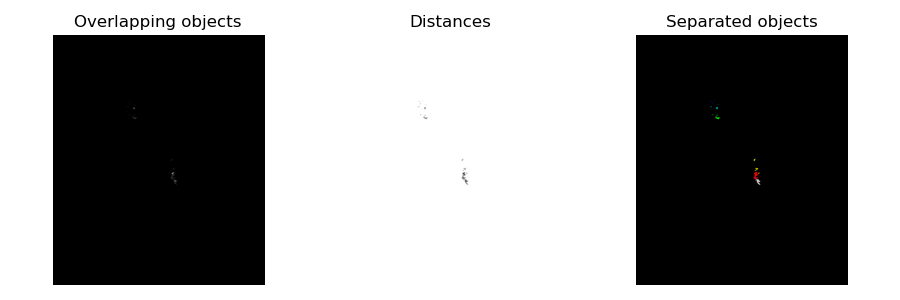

In [133]:
distance = ndi.distance_transform_edt(image)
coords = peak_local_max(distance, min_distance = 4, num_peaks_per_label = 1)#, labels = image)#, footprint=np.ones((3, 3)), labels=image)
mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, _ = ndi.label(mask)
labels = watershed(-distance, markers, mask=image)

#labels = watershed(image)

fig, axes = plt.subplots(ncols=3, figsize=(9, 3), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Overlapping objects')
ax[1].imshow(-distance, cmap=plt.cm.gray)
ax[1].set_title('Distances')
ax[2].imshow(labels, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Separated objects')

for a in ax:
    a.set_axis_off()

fig.tight_layout()
plt.show()